In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc, recall_score, f1_score, roc_auc_score
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline # Crucial pour la CV avec SMOTE

# Les 4 modèles demandés
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from sklearn.neural_network import MLPClassifier

sns.set(style="whitegrid")

# 1. Chargement
try:
    data = pd.read_csv("uci-secom.csv")
except:
    print("Erreur chargement fichier.")

# 2. Nettoyage initial
cols_to_drop = [c for c in ['Time', 'Phase'] if c in data.columns]
data = data.drop(columns=cols_to_drop)

X = data.drop(columns=['Pass/Fail'])
y = data['Pass/Fail'].replace({-1: 0}) 

# 3. SPLIT (La base)
# On garde 30% pour le test final. Tout le reste sert à la Validation Croisée.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

print(f"Train Set : {X_train.shape}")
print(f"Test Set  : {X_test.shape}")

Train Set : (1096, 590)
Test Set  : (471, 590)


In [11]:
# Liste des modèles à comparer (Section 3.3 du PDF)
models = {
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "AdaBoost": AdaBoostClassifier(n_estimators=50, random_state=42),
    "Neural Network": MLPClassifier(hidden_layer_sizes=(100,50), max_iter=500, random_state=42)
}

print(f"{'MODÈLE':<20} | {'AUC (CV)':<10} | {'RECALL (CV)':<10} | {'F1 (CV)':<10}")
print("-" * 65)

results = {}

# Boucle de Cross-Validation
# On coupe le Train set en 5 plis (Folds)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

for name, model in models.items():
    # Création du Pipeline pour ne pas faire de fuite de données (Leakage)
    # À chaque pli, on refait l'imputation, le scaling et le SMOTE
    pipeline = ImbPipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler()),
        ('smote', SMOTE(random_state=42)),
        ('classifier', model)
    ])
    
    # Calcul des scores par Validation Croisée (Section 3.4)
    # On mesure l'AUC, le Rappel et le F1
    auc_scores = cross_val_score(pipeline, X_train, y_train, cv=cv, scoring='roc_auc')
    rec_scores = cross_val_score(pipeline, X_train, y_train, cv=cv, scoring='recall')
    f1_scores  = cross_val_score(pipeline, X_train, y_train, cv=cv, scoring='f1')
    
    # Stockage
    results[name] = {
        'pipeline': pipeline, # On garde le pipeline pour l'entraîner plus tard
        'auc': auc_scores.mean(),
        'recall': rec_scores.mean()
    }
    
    print(f"{name:<20} | {auc_scores.mean():.4f}     | {rec_scores.mean():.4f}      | {f1_scores.mean():.4f}")

# Explication :
# Si un modèle a un bon score ici, c'est qu'il est ROBUSTE (il a réussi 5 fois de suite sur des données différentes).

MODÈLE               | AUC (CV)   | RECALL (CV) | F1 (CV)   
-----------------------------------------------------------------
Decision Tree        | 0.5361     | 0.1914      | 0.1355
Random Forest        | 0.6503     | 0.0133      | 0.0235
AdaBoost             | 0.6049     | 0.2467      | 0.1691
Neural Network       | 0.6288     | 0.0800      | 0.1045


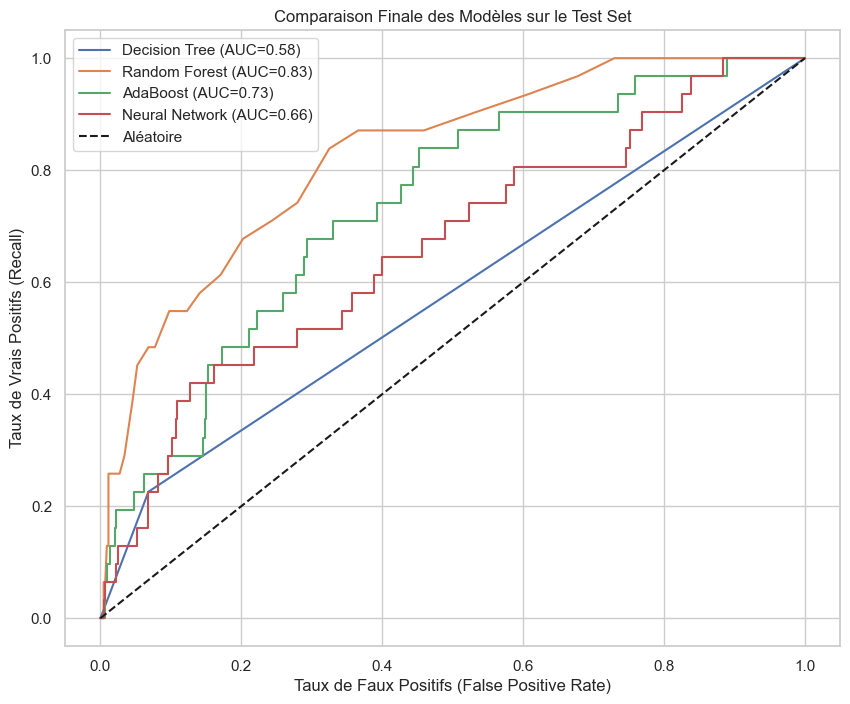

In [12]:
plt.figure(figsize=(10, 8))

# On ré-entraîne chaque pipeline sur TOUT le X_train et on teste sur X_test
for name, data_res in results.items():
    pipeline = data_res['pipeline']
    
    # Entraînement final
    pipeline.fit(X_train, y_train)
    
    # Prédiction sur le Test Set (jamais vu)
    if hasattr(pipeline['classifier'], "predict_proba"):
        y_prob = pipeline.predict_proba(X_test)[:, 1]
    else:
        y_prob = pipeline.predict(X_test)
        
    # Courbe ROC
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc_score = roc_auc_score(y_test, y_prob)
    
    plt.plot(fpr, tpr, label=f'{name} (AUC={auc_score:.2f})')

plt.plot([0, 1], [0, 1], 'k--', label='Aléatoire')
plt.xlabel('Taux de Faux Positifs (False Positive Rate)')
plt.ylabel('Taux de Vrais Positifs (Recall)')
plt.title('Comparaison Finale des Modèles sur le Test Set')
plt.legend()
plt.grid(True)
plt.show()

--- RÉSULTATS DÉTAILLÉS : Neural Network ---
              precision    recall  f1-score   support

           0       0.94      0.97      0.95       440
           1       0.22      0.13      0.16        31

    accuracy                           0.91       471
   macro avg       0.58      0.55      0.56       471
weighted avg       0.89      0.91      0.90       471



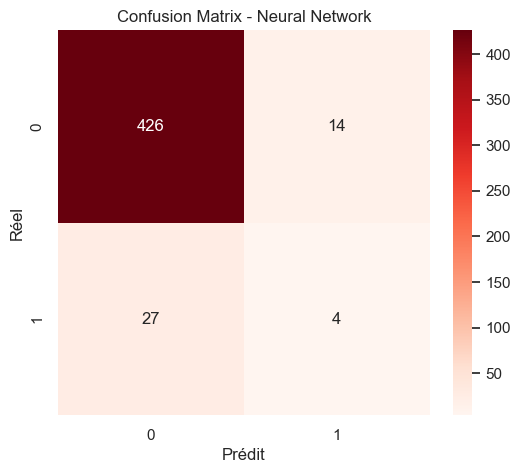

In [13]:
# Sélection du modèle (ici Neural Network par exemple)
best_name = "Neural Network"
best_pipeline = results[best_name]['pipeline']

# Prédictions finales
y_pred = best_pipeline.predict(X_test)

print(f"--- RÉSULTATS DÉTAILLÉS : {best_name} ---")
print(classification_report(y_test, y_pred))

# Matrice de Confusion
plt.figure(figsize=(6, 5))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Reds')
plt.title(f"Confusion Matrix - {best_name}")
plt.ylabel('Réel')
plt.xlabel('Prédit')
plt.show()

--- RÉSULTATS DÉTAILLÉS : AdaBoost ---
              precision    recall  f1-score   support

           0       0.95      0.92      0.93       440
           1       0.19      0.26      0.22        31

    accuracy                           0.88       471
   macro avg       0.57      0.59      0.58       471
weighted avg       0.90      0.88      0.89       471



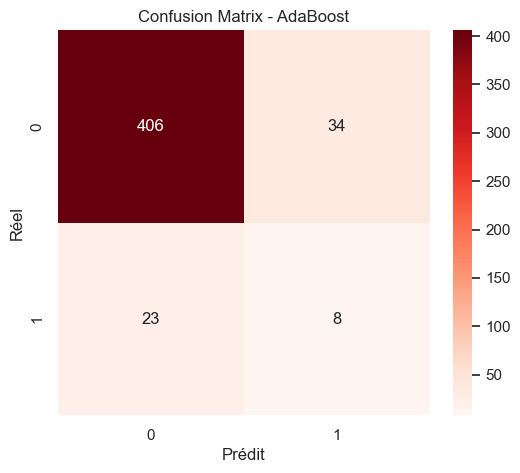

In [14]:
# Sélection du modèle (ici Neural Network par exemple)
best_name = "AdaBoost"
best_pipeline = results[best_name]['pipeline']

# Prédictions finales
y_pred = best_pipeline.predict(X_test)

print(f"--- RÉSULTATS DÉTAILLÉS : {best_name} ---")
print(classification_report(y_test, y_pred))

# Matrice de Confusion
plt.figure(figsize=(6, 5))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Reds')
plt.title(f"Confusion Matrix - {best_name}")
plt.ylabel('Réel')
plt.xlabel('Prédit')
plt.show()

--- RÉSULTATS DÉTAILLÉS : Random Forest ---
              precision    recall  f1-score   support

           0       0.93      1.00      0.96       440
           1       0.00      0.00      0.00        31

    accuracy                           0.93       471
   macro avg       0.47      0.50      0.48       471
weighted avg       0.87      0.93      0.90       471



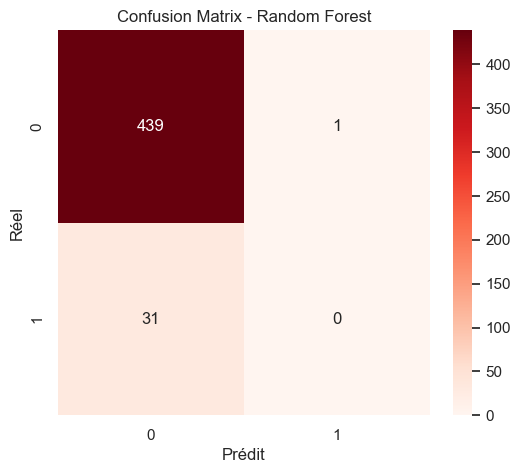

In [15]:
# Sélection du modèle (ici Neural Network par exemple)
best_name = "Random Forest"
best_pipeline = results[best_name]['pipeline']

# Prédictions finales
y_pred = best_pipeline.predict(X_test)

print(f"--- RÉSULTATS DÉTAILLÉS : {best_name} ---")
print(classification_report(y_test, y_pred))

# Matrice de Confusion
plt.figure(figsize=(6, 5))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Reds')
plt.title(f"Confusion Matrix - {best_name}")
plt.ylabel('Réel')
plt.xlabel('Prédit')
plt.show()

--- RÉSULTATS DÉTAILLÉS : Decision Tree ---
              precision    recall  f1-score   support

           0       0.94      0.93      0.94       440
           1       0.19      0.23      0.21        31

    accuracy                           0.89       471
   macro avg       0.57      0.58      0.57       471
weighted avg       0.89      0.89      0.89       471



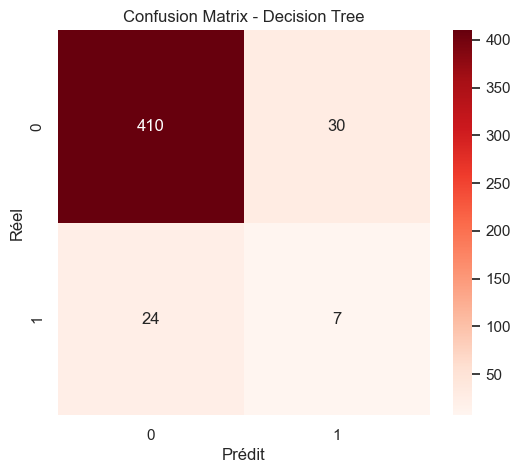

In [16]:
# Sélection du modèle (ici Neural Network par exemple)
best_name = "Decision Tree"
best_pipeline = results[best_name]['pipeline']

# Prédictions finales
y_pred = best_pipeline.predict(X_test)

print(f"--- RÉSULTATS DÉTAILLÉS : {best_name} ---")
print(classification_report(y_test, y_pred))

# Matrice de Confusion
plt.figure(figsize=(6, 5))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Reds')
plt.title(f"Confusion Matrix - {best_name}")
plt.ylabel('Réel')
plt.xlabel('Prédit')
plt.show()